# 1.6 情報理論 (Information Theory)

本ノートブックでは、機械学習やベイズ推論、深層生成モデルの基盤となる **情報理論 (Information Theory)** の数理を学びます。

PRML 第1章 1.6 節の主要トピック：
- **情報量 (Information Content)** と **シャノンエントロピー (Shannon Entropy)**
- **ベルヌーイ試行のエントロピー曲線 (PRML Figure 1.30)**
- **連続変数の微分エントロピー (Differential Entropy)** とガウス分布の最大エントロピー性
- **カルバック・ライブラー情報量 (Kullback-Leibler Divergence, KLダイバージェンス)**
- **KLダイバージェンスの非対称性 ($KL(p||q)$ vs $KL(q||p)$)** と変分近似・モーメントマッチングの幾何学
- **相互情報量 (Mutual Information)** と変数の統計的独立性

を Python による数理導出・数値積分・完全可視化を通じて探求します。

## 1.6.1 シャノンエントロピー (Shannon Entropy)

確率 $p(x)$ で生起する事象の情報量は：
$$ h(x) = -\log_2 p(x) $$
と定義されます。離散確率変数 $X$ の平均情報量（シャノンエントロピー）は：
$$ H[X] = -\sum_{x} p(x) \log_2 p(x) $$
です。

### ベルヌーイ分布のエントロピー (PRML Figure 1.30)
表が出る確率が $p$ であるコイン投げのエントロピー：
$$ H(p) = -p \log_2 p - (1-p) \log_2 (1-p) $$
は、$p = 0.5$（最も不確実性が高い状態）で最大値 $1$ ビットを達成します。

Plot saved to: result/fig1_30_bernoulli_entropy.png


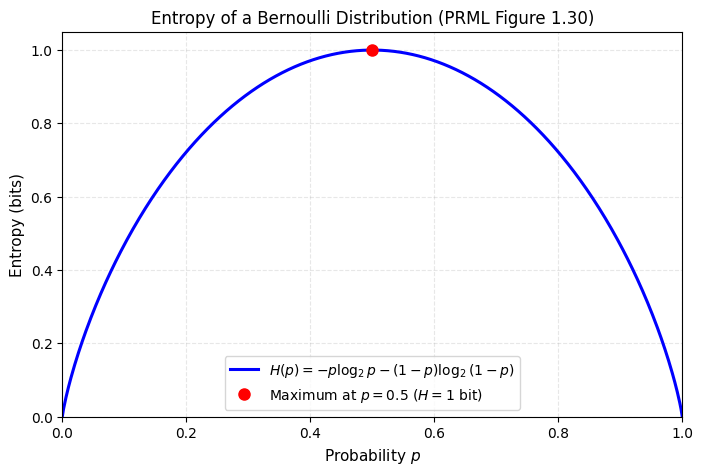

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

p = np.linspace(1e-6, 1.0 - 1e-6, 500)
# ベルヌーイエントロピー (bit)
entropy = -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p, entropy, 'b-', lw=2.2, label=r'$H(p) = -p \log_2 p - (1-p)\log_2(1-p)$')
ax.plot(0.5, 1.0, 'ro', markersize=8, label=r'Maximum at $p=0.5$ ($H=1$ bit)')

ax.set_title('Entropy of a Bernoulli Distribution (PRML Figure 1.30)', fontsize=12)
ax.set_xlabel('Probability $p$', fontsize=11)
ax.set_ylabel('Entropy (bits)', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower center', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig1_30_bernoulli_entropy.png')
plt.show()

## 1.6.2 微分エントロピー (Differential Entropy)

連続確率変数 $x$ の確率密度関数 $p(x)$ に対する微分エントロピーは以下で定義されます：
$$ H[x] = -\int p(x) \ln p(x) dx $$

### ガウス分布の微分エントロピー
1次元正規分布 $\mathcal{N}(x|\mu, \sigma^2)$ に対する微分エントロピーは：
$$ H[x] = \frac{1}{2} \left\{ 1 + \ln(2\pi \sigma^2) \right\} $$
と解析的に求まります。
分散 $\sigma^2$ が固定されているとき、**すべての連続確率分布の中でエントロピーを最大化するのは正規分布** であることが変分法（ラグランジュ未定乗数法）によって証明されます（PRML 演習 1.34）。

分散 sigma^2 = 1.0 に固定したときの微分エントロピー比較 (nats):
  ガウス分布 (Gaussian):   1.4189 nats (最大)
  ラプラス分布 (Laplace):  1.3466 nats
  一様分布 (Uniform):      1.2425 nats
Plot saved to: result/fig1_max_entropy_distributions.png


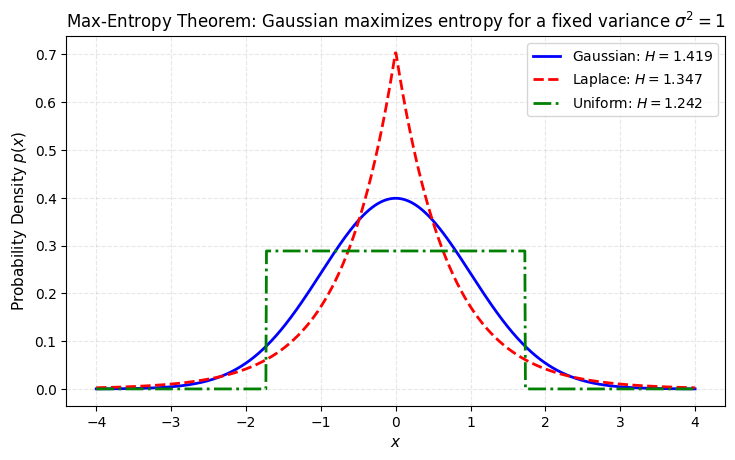

In [2]:
from scipy.stats import norm, laplace, uniform

# 同じ分散 sigma^2 = 1.0 を持つ異なる分布の微分エントロピーの比較
sigma2 = 1.0
sigma = np.sqrt(sigma2)

# 1. 正規分布 N(0, sigma^2)
h_gauss_analytical = 0.5 * (1.0 + np.log(2 * np.pi * sigma2))

# 2. ラプラス分布 (分散 = 2 * b^2 = 1 => b = 1/sqrt(2))
b = 1.0 / np.sqrt(2.0)
h_laplace_analytical = 1.0 + np.log(2 * b)

# 3. 一様分布 U(-a, a) (分散 = (2a)^2 / 12 = a^2 / 3 = 1 => a = sqrt(3))
a = np.sqrt(3.0)
h_uniform_analytical = np.log(2 * a)

print(f"分散 sigma^2 = {sigma2} に固定したときの微分エントロピー比較 (nats):")
print(f"  ガウス分布 (Gaussian):   {h_gauss_analytical:.4f} nats (最大)")
print(f"  ラプラス分布 (Laplace):  {h_laplace_analytical:.4f} nats")
print(f"  一様分布 (Uniform):      {h_uniform_analytical:.4f} nats")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x_axis = np.linspace(-4, 4, 1000)

ax.plot(x_axis, norm.pdf(x_axis, 0, sigma), 'b-', lw=2.0, label=f'Gaussian: $H={h_gauss_analytical:.3f}$')
ax.plot(x_axis, laplace.pdf(x_axis, 0, b), 'r--', lw=2.0, label=f'Laplace: $H={h_laplace_analytical:.3f}$')
ax.plot(x_axis, uniform.pdf(x_axis, -a, 2*a), 'g-.', lw=2.0, label=f'Uniform: $H={h_uniform_analytical:.3f}$')

ax.set_title(r'Max-Entropy Theorem: Gaussian maximizes entropy for a fixed variance $\sigma^2=1$', fontsize=12)
ax.set_xlabel('$x$', fontsize=11); ax.set_ylabel('Probability Density $p(x)$', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig1_max_entropy_distributions.png')
plt.show()

## 1.6.3 相対エントロピー (KLダイバージェンス) とその非対称性

未知の真の分布 $p(x)$ を近似分布 $q(x)$ でモデル化したときの情報の相対損失を測るのが **カルバック・ライブラー情報量 (Kullback-Leibler Divergence)** です：
$$
KL(p \parallel q) = -\int p(x) \ln \frac{q(x)}{p(x)} dx = \int p(x) \ln \frac{p(x)}{q(x)} dx
$$
イェンセンの不等式 $-\ln x$ の凸性により常に $KL(p \parallel q) \ge 0$ であり、$p(x) = q(x)$ のときのみ $0$ になります。

### $KL(p \parallel q)$ と $KL(q \parallel p)$ の非対称性
- **順方向 $KL(p \parallel q)$ (Forward KL / Zero-Avoiding / Moment Matching)**:
  $p(x) > 0$ の領域で $q(x)$ が $0$ になると発散するため、$q(x)$ は $p(x)$ の全領域を広く覆うように広がります（過大分散）。
- **逆方向 $KL(q \parallel p)$ (Reverse KL / Zero-Forcing / Mode Seeking)**:
  $p(x) \approx 0$ の領域で $q(x) > 0$ になるとペナルティが大きいため、$q(x)$ は $p(x)$ のいずれか1つの最頻値（モード）に収縮します（過小分散）。これは変分推論（第10章）の基礎となります。

Plot saved to: result/fig1_kl_asymmetry.png


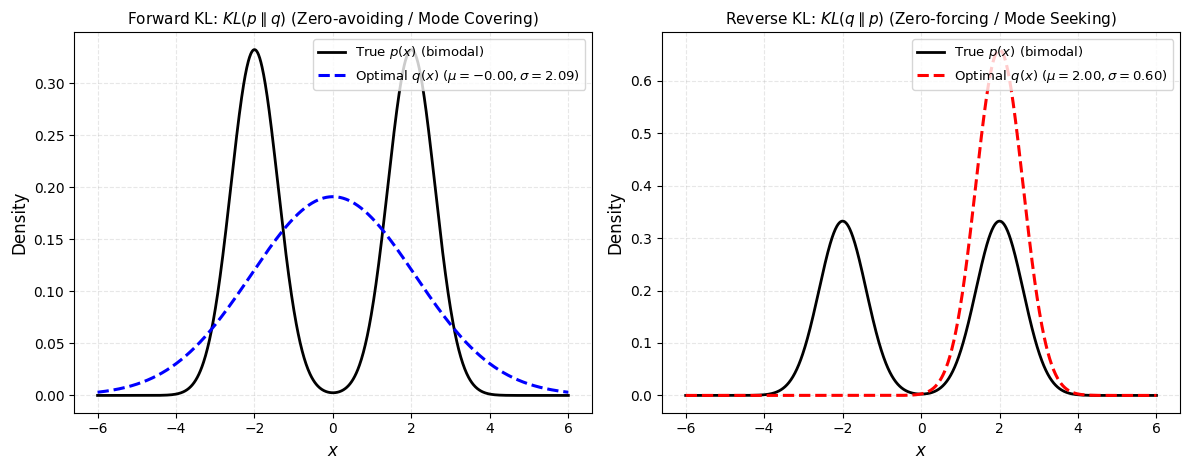

In [3]:
# 2峰性混合ガウス分布 p(x) を単峰ガウス分布 q(x|mu, sigma^2) で近似
from scipy.optimize import minimize

# 真の分布: 0.5 * N(-2, 0.5^2) + 0.5 * N(2, 0.5^2)
def p_true(x):
    return 0.5 * norm.pdf(x, -2.0, 0.6) + 0.5 * norm.pdf(x, 2.0, 0.6)

x_grid = np.linspace(-6, 6, 1200)
dx = x_grid[1] - x_grid[0]
p_vals = p_true(x_grid)

# Forward KL: \int p(x) \ln(p(x)/q(x)) dx
def loss_forward_kl(params):
    mu, log_sig = params
    sig = np.exp(log_sig)
    q_vals = norm.pdf(x_grid, mu, sig) + 1e-12
    return np.sum(p_vals * np.log((p_vals + 1e-12) / q_vals)) * dx

# Reverse KL: \int q(x) \ln(q(x)/p(x)) dx
def loss_reverse_kl(params):
    mu, log_sig = params
    sig = np.exp(log_sig)
    q_vals = norm.pdf(x_grid, mu, sig) + 1e-12
    return np.sum(q_vals * np.log(q_vals / (p_vals + 1e-12))) * dx

res_fwd = minimize(loss_forward_kl, [0.0, 0.5], method='Nelder-Mead')
res_rev = minimize(loss_reverse_kl, [2.0, 0.0], method='Nelder-Mead')

mu_fwd, sig_fwd = res_fwd.x[0], np.exp(res_fwd.x[1])
mu_rev, sig_rev = res_rev.x[0], np.exp(res_rev.x[1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

# Forward KL Plot
ax1.plot(x_grid, p_vals, 'k-', lw=2.0, label='True $p(x)$ (bimodal)')
ax1.plot(x_grid, norm.pdf(x_grid, mu_fwd, sig_fwd), 'b--', lw=2.2,
         label=f'Optimal $q(x)$ ($\mu={mu_fwd:.2f}, \sigma={sig_fwd:.2f}$)')
ax1.set_title(r'Forward KL: $KL(p \parallel q)$ (Zero-avoiding / Mode Covering)', fontsize=11)
ax1.set_xlabel('$x$'); ax1.set_ylabel('Density')
ax1.legend(loc='upper right', fontsize=9.5)
ax1.grid(True, linestyle='--', alpha=0.3)

# Reverse KL Plot
ax2.plot(x_grid, p_vals, 'k-', lw=2.0, label='True $p(x)$ (bimodal)')
ax2.plot(x_grid, norm.pdf(x_grid, mu_rev, sig_rev), 'r--', lw=2.2,
         label=f'Optimal $q(x)$ ($\mu={mu_rev:.2f}, \sigma={sig_rev:.2f}$)')
ax2.set_title(r'Reverse KL: $KL(q \parallel p)$ (Zero-forcing / Mode Seeking)', fontsize=11)
ax2.set_xlabel('$x$'); ax2.set_ylabel('Density')
ax2.legend(loc='upper right', fontsize=9.5)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_kl_asymmetry.png')
plt.show()

## 1.6.4 相互情報量 (Mutual Information)

2つの確率変数 $X$ と $Y$ の同時確率 $p(\mathbf{x}, \mathbf{y})$ と、独立を仮定した積 $p(\mathbf{x})p(\mathbf{y})$ との間の KL ダイバージェンスを **相互情報量 (Mutual Information)** と呼びます（PRML 式 1.120）：
$$
I(\mathbf{x}, \mathbf{y}) = KL(p(\mathbf{x}, \mathbf{y}) \parallel p(\mathbf{x})p(\mathbf{y})) = -\iint p(\mathbf{x}, \mathbf{y}) \ln \left( \frac{p(\mathbf{x})p(\mathbf{y})}{p(\mathbf{x}, \mathbf{y})} \right) d\mathbf{x} d\mathbf{y}
$$
相互情報量は以下の直感的・対称的な恒等式を満たします：
$$
I(\mathbf{x}, \mathbf{y}) = H[\mathbf{x}] - H[\mathbf{x}|\mathbf{y}] = H[\mathbf{y}] - H[\mathbf{y}|\mathbf{x}] \ge 0
$$
$\mathbf{x}$ と $\mathbf{y}$ が互いに統計的独立であるとき、かつそのときに限り $I(\mathbf{x}, \mathbf{y}) = 0$ となります。

## まとめ

本節では情報理論の重要概念を実装しました：
1. **シャノンエントロピー**: 不確実性の定量的尺度であり、均一な分布で最大化。
2. **微分エントロピー**: 連続変数への拡張。分散固定の条件下で正規分布が最大エントロピーを達成。
3. **KLダイバージェンス**: 分布間の距離尺度。非対称性（$KL(p||q)$ は全体を包括、$KL(q||p)$ は特定ピークに局在）は変分推論（第10章）の核心原理。
4. **相互情報量**: 変数間の非線形な依存関係を測る普遍的尺度。